Classifying high vs. low fat meat using derivatives and scalar features
=========================================================================

Binary classification of meat samples as high- or low-fat based on their 
infrared spectrometric curves and associated scalar features.

In [59]:
from skfda.datasets import fetch_tecator

X_df, y_df = fetch_tecator(return_X_y=True, as_frame=True)

fd = X_df.iloc[:, 0].array  # Infrared spectra
fat = y_df["fat"].to_numpy()
water = y_df["water"].to_numpy()
protein = y_df["protein"].to_numpy()

In [60]:
import numpy as np

fat_threshold = 20
low_fat = fat < fat_threshold
labels = np.where(low_fat, "low fat", "high fat")
y = np.where(low_fat, 0, 1)  # 0 = low fat, 1 = high fat (binary label)

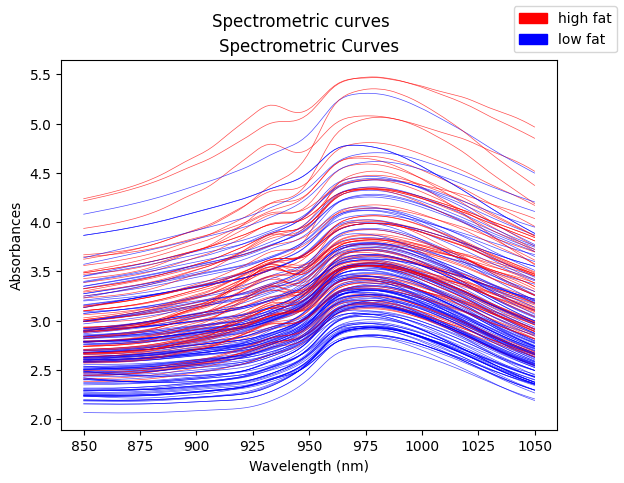

In [61]:
import matplotlib.pyplot as plt

colors = {
    "high fat": "red",
    "low fat": "blue",
}

fd.plot(
    group=labels,
    group_colors=colors,
    linewidth=0.5,
    alpha=0.7,
    legend=True,
)
plt.title("Spectrometric Curves")
plt.show()

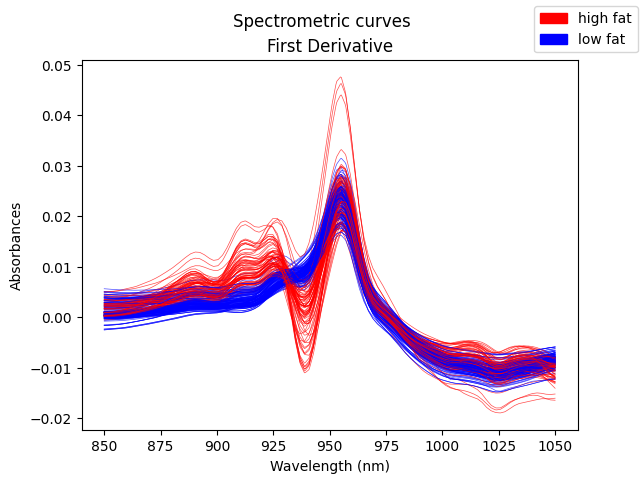

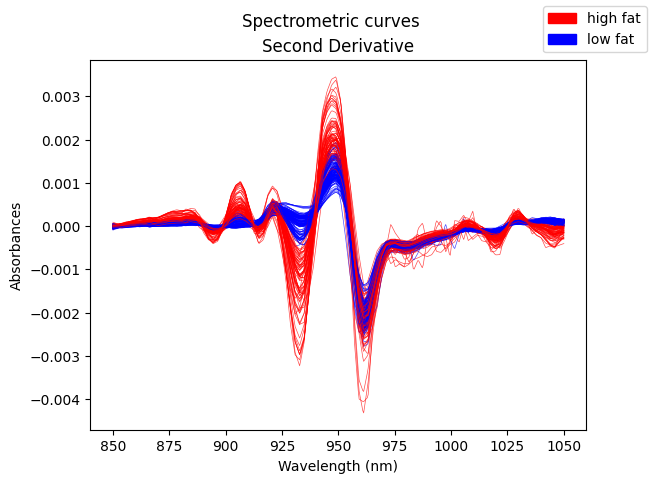

In [62]:
fd_1st = fd.derivative()
fd_2nd = fd.derivative(order=2)

fd_1st.plot(
    group=labels,
    group_colors=colors,
    linewidth=0.5,
    alpha=0.7,
    legend=True,
)
plt.title("First Derivative")
plt.show()

fd_2nd.plot(
    group=labels,
    group_colors=colors,
    linewidth=0.5,
    alpha=0.7,
    legend=True,
)
plt.title("Second Derivative")
plt.show()

In [63]:
import pandas as pd

df_scalar = pd.DataFrame({
    "water": water,
    "protein": protein,
    "fat_group": labels,
})

print(df_scalar.groupby("fat_group").describe())

           water                                                        \
           count       mean       std   min     25%    50%   75%   max   
fat_group                                                                
high fat    77.0  51.749351  6.389354  39.3  48.600  52.90  56.6  62.4   
low fat    138.0  69.596014  3.953618  59.7  66.325  70.75  72.6  76.6   

          protein                                                        
            count       mean      std   min     25%   50%     75%   max  
fat_group                                                                
high fat     77.0  14.651948  2.15068  11.0  13.200  15.0  16.000  19.3  
low fat     138.0  19.373913  1.89884  11.6  18.825  19.6  20.675  21.8  
